# HR Analytics — Employee Attrition Analysis
## Who is leaving, why, and who is at risk next?

**Business Question:** What drives employee attrition at this company, 
which departments and roles are most affected, and which active employees 
are most likely to leave next?

**Dataset:** IBM HR Analytics Employee Attrition | 1,470 employees | 35 features  
**Tools:** Python, SQLite, pandas, scikit-learn, matplotlib, seaborn

In [1]:
import pandas as pd
import numpy as np
import sqlite3
import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda x: '%.2f' % x)
pd.set_option('display.max_columns', 40)

print("All libraries loaded successfully")

All libraries loaded successfully


## Step 1: Load & Inspect Data

In [2]:
df = pd.read_csv('../Data/hr_attrition.csv')

print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nAttrition breakdown:")
print(df['Attrition'].value_counts())
print(f"\nAttrition rate: {(df['Attrition']=='Yes').mean()*100:.2f}%")
print(f"\nMissing values: {df.isnull().sum().sum()}")
df.head(3)

Shape: (1470, 35)

Columns: ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Attrition breakdown:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition rate: 16.12%

Missing values: 0


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0


## Step 2: Data Cleaning

This dataset is already clean — no missing values, no duplicates.
Key cleaning steps:
- Create binary attrition column (1 = left, 0 = stayed)
- Drop columns with zero variance (EmployeeCount, Over18, StandardHours)
- These columns have the same value for every employee — useless for analysis

In [4]:
# Binary target column
df['Attrition_Binary'] = (df['Attrition'] == 'Yes').astype(int)

# Drop zero-variance columns
zero_var_cols = ['EmployeeCount', 'Over18', 'StandardHours']
df_clean = df.drop(columns=zero_var_cols)

# Create salary bands
df_clean['SalaryBand'] = pd.cut(df_clean['MonthlyIncome'],
    bins=[0, 3000, 6000, 10000, 20000],
    labels=['Low (<3K)', 'Mid (3-6K)', 'High (6-10K)', 'Very High (10K+)'])

# Create tenure bands
df_clean['TenureBand'] = pd.cut(df_clean['YearsAtCompany'],
    bins=[-1, 2, 5, 10, 40],
    labels=['0-2 yrs', '3-5 yrs', '6-10 yrs', '10+ yrs'])

print(f"Clean dataset: {df_clean.shape}")
print(f"\nAttrition rate       : {df_clean['Attrition_Binary'].mean()*100:.2f}%")
print(f"Employees who left   : {df_clean['Attrition_Binary'].sum()}")
print(f"Employees who stayed : {(df_clean['Attrition_Binary']==0).sum()}")
print(f"\nDepartments: {df_clean['Department'].unique()}")
print(f"Job Roles  : {df_clean['JobRole'].unique()}")

Clean dataset: (1470, 35)

Attrition rate       : 16.12%
Employees who left   : 237
Employees who stayed : 1233

Departments: ['Sales' 'Research & Development' 'Human Resources']
Job Roles  : ['Sales Executive' 'Research Scientist' 'Laboratory Technician'
 'Manufacturing Director' 'Healthcare Representative' 'Manager'
 'Sales Representative' 'Research Director' 'Human Resources']


## Step 3: SQL Analysis Layer

6 business queries that answer the key HR leadership questions —
loaded into SQLite for clean, reusable query documentation.

In [5]:
conn = sqlite3.connect(':memory:')
df_clean.to_sql('employees', conn, index=False, if_exists='replace')

print("Data loaded into SQLite")
print(f"Table 'employees': {pd.read_sql('SELECT COUNT(*) as n FROM employees', conn)['n'][0]:,} rows")

Data loaded into SQLite
Table 'employees': 1,470 rows


In [6]:
q1 = """
SELECT
    Department,
    COUNT(*)                                          AS total_employees,
    SUM(Attrition_Binary)                             AS employees_left,
    ROUND(SUM(Attrition_Binary)*100.0/COUNT(*), 2)   AS attrition_rate_pct,
    ROUND(AVG(MonthlyIncome), 2)                      AS avg_monthly_income
FROM employees
GROUP BY Department
ORDER BY attrition_rate_pct DESC
"""
dept_attrition = pd.read_sql(q1, conn)
print("=== QUERY 1: ATTRITION BY DEPARTMENT ===")
print(dept_attrition.to_string(index=False))

=== QUERY 1: ATTRITION BY DEPARTMENT ===
            Department  total_employees  employees_left  attrition_rate_pct  avg_monthly_income
                 Sales              446              92               20.63             6959.17
       Human Resources               63              12               19.05             6654.51
Research & Development              961             133               13.84             6281.25


In [7]:
q2 = """
SELECT
    JobRole,
    COUNT(*)                                          AS total_employees,
    SUM(Attrition_Binary)                             AS employees_left,
    ROUND(SUM(Attrition_Binary)*100.0/COUNT(*), 2)   AS attrition_rate_pct,
    ROUND(AVG(MonthlyIncome), 2)                      AS avg_income
FROM employees
GROUP BY JobRole
ORDER BY attrition_rate_pct DESC
"""
role_attrition = pd.read_sql(q2, conn)
print("=== QUERY 2: ATTRITION BY JOB ROLE ===")
print(role_attrition.to_string(index=False))

=== QUERY 2: ATTRITION BY JOB ROLE ===
                  JobRole  total_employees  employees_left  attrition_rate_pct  avg_income
     Sales Representative               83              33               39.76     2626.00
    Laboratory Technician              259              62               23.94     3237.17
          Human Resources               52              12               23.08     4235.75
          Sales Executive              326              57               17.48     6924.28
       Research Scientist              292              47               16.10     3239.97
   Manufacturing Director              145              10                6.90     7295.14
Healthcare Representative              131               9                6.87     7528.76
                  Manager              102               5                4.90    17181.68
        Research Director               80               2                2.50    16033.55


In [8]:
q3 = """
SELECT
    SalaryBand,
    COUNT(*)                                          AS total_employees,
    SUM(Attrition_Binary)                             AS employees_left,
    ROUND(SUM(Attrition_Binary)*100.0/COUNT(*), 2)   AS attrition_rate_pct
FROM employees
GROUP BY SalaryBand
ORDER BY attrition_rate_pct DESC
"""
salary_attrition = pd.read_sql(q3, conn)
print("=== QUERY 3: ATTRITION BY SALARY BAND ===")
print(salary_attrition.to_string(index=False))

=== QUERY 3: ATTRITION BY SALARY BAND ===
      SalaryBand  total_employees  employees_left  attrition_rate_pct
       Low (<3K)              395             113               28.61
      Mid (3-6K)              519              66               12.72
    High (6-10K)              275              33               12.00
Very High (10K+)              281              25                8.90


In [9]:
q4 = """
SELECT
    Attrition,
    ROUND(AVG(JobSatisfaction), 2)        AS avg_job_satisfaction,
    ROUND(AVG(EnvironmentSatisfaction),2) AS avg_env_satisfaction,
    ROUND(AVG(WorkLifeBalance), 2)        AS avg_work_life_balance,
    ROUND(AVG(RelationshipSatisfaction),2)AS avg_relationship_satisfaction,
    ROUND(AVG(MonthlyIncome), 2)          AS avg_monthly_income,
    COUNT(*)                              AS employee_count
FROM employees
GROUP BY Attrition
"""
satisfaction = pd.read_sql(q4, conn)
print("=== QUERY 4: SATISFACTION SCORES — LEFT vs STAYED ===")
print(satisfaction.to_string(index=False))

=== QUERY 4: SATISFACTION SCORES — LEFT vs STAYED ===
Attrition  avg_job_satisfaction  avg_env_satisfaction  avg_work_life_balance  avg_relationship_satisfaction  avg_monthly_income  employee_count
       No                  2.78                  2.77                   2.78                           2.73             6832.74            1233
      Yes                  2.47                  2.46                   2.66                           2.60             4787.09             237


In [10]:
q5 = """
SELECT
    TenureBand,
    COUNT(*)                                          AS total_employees,
    SUM(Attrition_Binary)                             AS employees_left,
    ROUND(SUM(Attrition_Binary)*100.0/COUNT(*), 2)   AS attrition_rate_pct
FROM employees
GROUP BY TenureBand
ORDER BY attrition_rate_pct DESC
"""
tenure_attrition = pd.read_sql(q5, conn)
print("=== QUERY 5: ATTRITION BY TENURE BAND ===")
print(tenure_attrition.to_string(index=False))

=== QUERY 5: ATTRITION BY TENURE BAND ===
TenureBand  total_employees  employees_left  attrition_rate_pct
   0-2 yrs              342             102               29.82
   3-5 yrs              434              60               13.82
  6-10 yrs              448              55               12.28
   10+ yrs              246              20                8.13


In [11]:
q6 = """
SELECT
    OverTime,
    COUNT(*)                                          AS total_employees,
    SUM(Attrition_Binary)                             AS employees_left,
    ROUND(SUM(Attrition_Binary)*100.0/COUNT(*), 2)   AS attrition_rate_pct,
    ROUND(AVG(MonthlyIncome), 2)                      AS avg_income
FROM employees
GROUP BY OverTime
ORDER BY attrition_rate_pct DESC
"""
overtime_attrition = pd.read_sql(q6, conn)
print("=== QUERY 6: OVERTIME vs ATTRITION ===")
print(overtime_attrition.to_string(index=False))

=== QUERY 6: OVERTIME vs ATTRITION ===
OverTime  total_employees  employees_left  attrition_rate_pct  avg_income
     Yes              416             127               30.53     6548.55
      No             1054             110               10.44     6484.93


In [12]:
sql_content = """
-- ================================================
-- HR Analytics — Employee Attrition SQL Queries
-- Author: Parshwa Shah
-- Dataset: IBM HR Analytics Employee Attrition
-- ================================================

-- Query 1: Attrition by Department
SELECT
    Department,
    COUNT(*)                                        AS total_employees,
    SUM(Attrition_Binary)                           AS employees_left,
    ROUND(SUM(Attrition_Binary)*100.0/COUNT(*),2)  AS attrition_rate_pct,
    ROUND(AVG(MonthlyIncome), 2)                    AS avg_monthly_income
FROM employees
GROUP BY Department
ORDER BY attrition_rate_pct DESC;

-- Query 2: Attrition by Job Role
SELECT
    JobRole,
    COUNT(*)                                        AS total_employees,
    SUM(Attrition_Binary)                           AS employees_left,
    ROUND(SUM(Attrition_Binary)*100.0/COUNT(*),2)  AS attrition_rate_pct,
    ROUND(AVG(MonthlyIncome), 2)                    AS avg_income
FROM employees
GROUP BY JobRole
ORDER BY attrition_rate_pct DESC;

-- Query 3: Attrition by Salary Band
SELECT
    SalaryBand,
    COUNT(*)                                        AS total_employees,
    SUM(Attrition_Binary)                           AS employees_left,
    ROUND(SUM(Attrition_Binary)*100.0/COUNT(*),2)  AS attrition_rate_pct
FROM employees
GROUP BY SalaryBand
ORDER BY attrition_rate_pct DESC;

-- Query 4: Satisfaction Scores — Left vs Stayed
SELECT
    Attrition,
    ROUND(AVG(JobSatisfaction), 2)         AS avg_job_satisfaction,
    ROUND(AVG(EnvironmentSatisfaction), 2) AS avg_env_satisfaction,
    ROUND(AVG(WorkLifeBalance), 2)         AS avg_work_life_balance,
    ROUND(AVG(MonthlyIncome), 2)           AS avg_monthly_income,
    COUNT(*)                               AS employee_count
FROM employees
GROUP BY Attrition;

-- Query 5: Attrition by Tenure Band
SELECT
    TenureBand,
    COUNT(*)                                        AS total_employees,
    SUM(Attrition_Binary)                           AS employees_left,
    ROUND(SUM(Attrition_Binary)*100.0/COUNT(*),2)  AS attrition_rate_pct
FROM employees
GROUP BY TenureBand
ORDER BY attrition_rate_pct DESC;

-- Query 6: Overtime vs Attrition
SELECT
    OverTime,
    COUNT(*)                                        AS total_employees,
    SUM(Attrition_Binary)                           AS employees_left,
    ROUND(SUM(Attrition_Binary)*100.0/COUNT(*),2)  AS attrition_rate_pct,
    ROUND(AVG(MonthlyIncome), 2)                    AS avg_income
FROM employees
GROUP BY OverTime
ORDER BY attrition_rate_pct DESC;
"""

os.makedirs('../SQL', exist_ok=True)
with open('../SQL/hr_attrition_queries.sql', 'w') as f:
    f.write(sql_content)
print("SQL file saved to /SQL/hr_attrition_queries.sql")

SQL file saved to /SQL/hr_attrition_queries.sql


### SQL Analysis Summary

| Query | Key Finding |
|-------|-------------|
| Department | Sales: 20.63% attrition — highest. R&D: 13.84%. HR: 19.05% |
| Job Role | Sales Rep: 39.76% — highest. Lab Technician: 23.94%. Manager: 4.90% |
| Salary Band | Low (<$3K): 28.61% attrition vs Very High (10K+): 8.90% — 3.2x difference |
| Satisfaction | Employees who left scored lower on ALL 4 satisfaction metrics |
| Tenure | 0-2 year employees: 29.82% attrition — drops to 8.13% at 10+ years |
| Overtime | Overtime workers: 30.53% attrition vs 10.44% non-overtime — 3x higher |

**The SQL layer reveals 4 clear attrition drivers:**
1. Sales Representatives are leaving at nearly 40% — a crisis-level rate
2. Low-salary employees churn at 3x the rate of high earners
3. New employees (0-2 years) are the highest risk — onboarding is broken
4. Overtime workers churn at 3x the rate — overwork is a major driver

## Step 4: Exploratory Data Analysis

5 visualizations that tell the complete attrition story visually.
Each chart answers a specific HR leadership question.

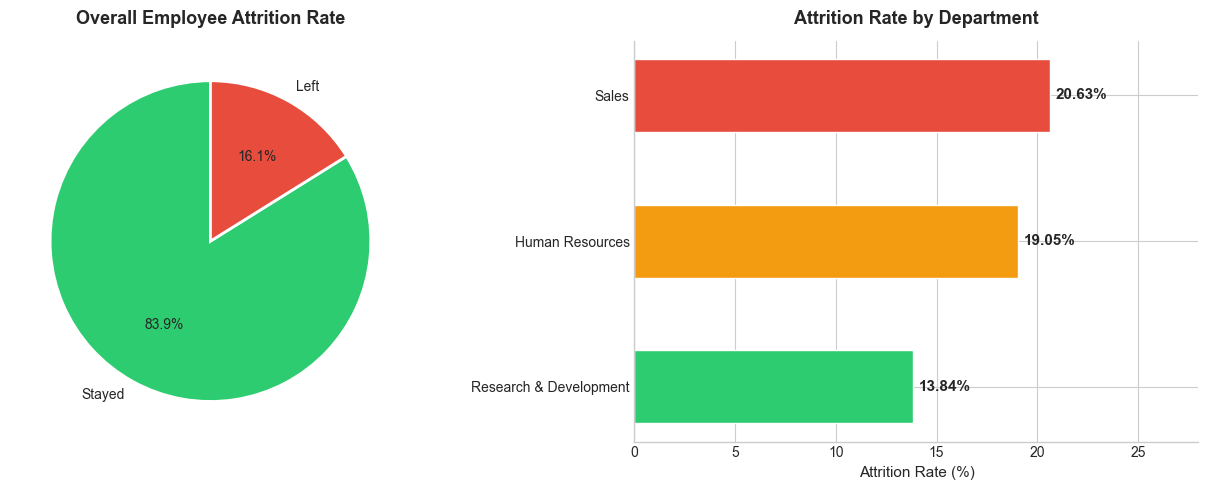

Chart saved!


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Chart 1: Overall attrition donut
attrition_counts = df_clean['Attrition'].value_counts()
colors_a = ['#2ECC71', '#E74C3C']
axes[0].pie(attrition_counts.values,
            labels=['Stayed', 'Left'],
            autopct='%1.1f%%',
            colors=colors_a,
            startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Overall Employee Attrition Rate',
                  fontsize=13, fontweight='bold', pad=12)

# Chart 2: Attrition rate by department
dept_plot = dept_attrition.sort_values('attrition_rate_pct', ascending=True)
colors_d  = ['#2ECC71', '#F39C12', '#E74C3C']
bars = axes[1].barh(dept_plot['Department'],
                    dept_plot['attrition_rate_pct'],
                    color=colors_d, edgecolor='white', height=0.5)
for bar, val in zip(bars, dept_plot['attrition_rate_pct']):
    axes[1].text(val + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val}%', va='center', fontsize=11, fontweight='bold')
axes[1].set_title('Attrition Rate by Department',
                  fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel('Attrition Rate (%)', fontsize=11)
axes[1].set_xlim(0, 28)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../Visuals/01_attrition_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

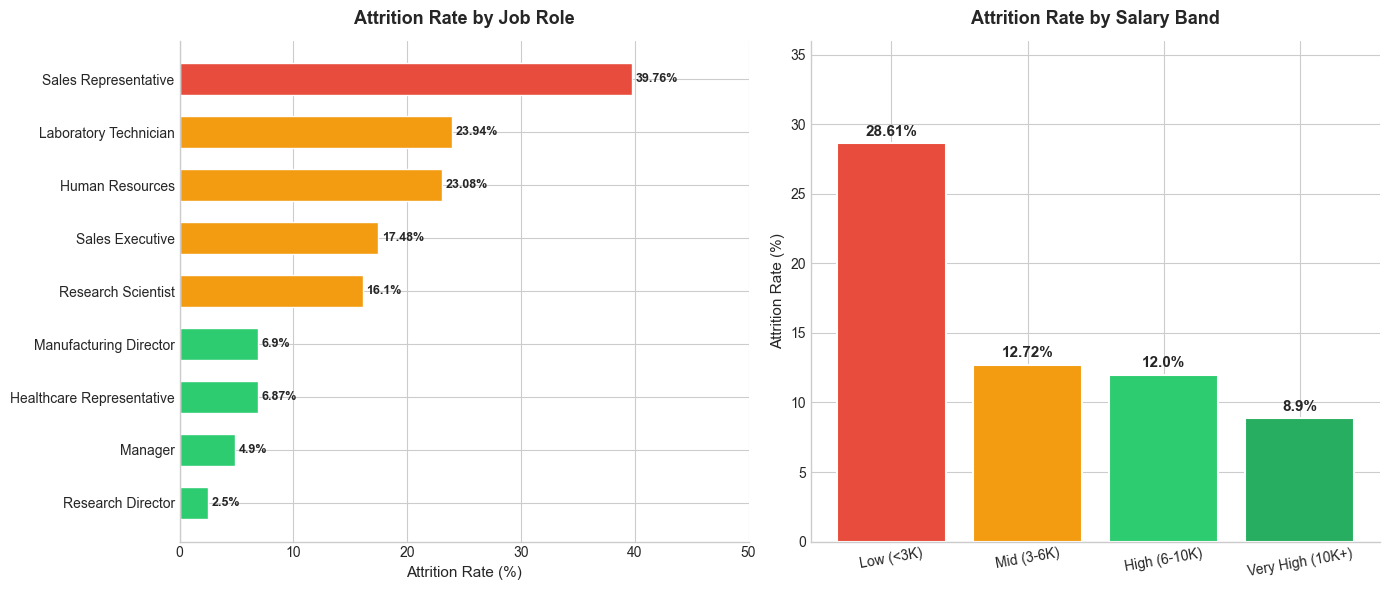

Chart saved!


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1: Attrition rate by job role
role_plot = role_attrition.sort_values('attrition_rate_pct', ascending=True)
colors_r  = ['#2ECC71' if v < 15 else '#F39C12' if v < 25 else '#E74C3C'
             for v in role_plot['attrition_rate_pct']]
bars = axes[0].barh(role_plot['JobRole'],
                    role_plot['attrition_rate_pct'],
                    color=colors_r, edgecolor='white', height=0.6)
for bar, val in zip(bars, role_plot['attrition_rate_pct']):
    axes[0].text(val + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val}%', va='center', fontsize=9, fontweight='bold')
axes[0].set_title('Attrition Rate by Job Role',
                  fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel('Attrition Rate (%)', fontsize=11)
axes[0].set_xlim(0, 50)
axes[0].spines[['top', 'right']].set_visible(False)

# Chart 2: Attrition rate by salary band
sal_order  = ['Low (<3K)', 'Mid (3-6K)', 'High (6-10K)', 'Very High (10K+)']
sal_colors = ['#E74C3C', '#F39C12', '#2ECC71', '#27AE60']
sal_plot   = salary_attrition.set_index('SalaryBand').reindex(sal_order).reset_index()
bars2 = axes[1].bar(sal_plot['SalaryBand'],
                    sal_plot['attrition_rate_pct'],
                    color=sal_colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars2, sal_plot['attrition_rate_pct']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f'{val}%', ha='center', va='bottom',
                 fontsize=11, fontweight='bold')
axes[1].set_title('Attrition Rate by Salary Band',
                  fontsize=13, fontweight='bold', pad=12)
axes[1].set_ylabel('Attrition Rate (%)', fontsize=11)
axes[1].set_ylim(0, 36)
axes[1].tick_params(axis='x', rotation=10)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../Visuals/02_role_and_salary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

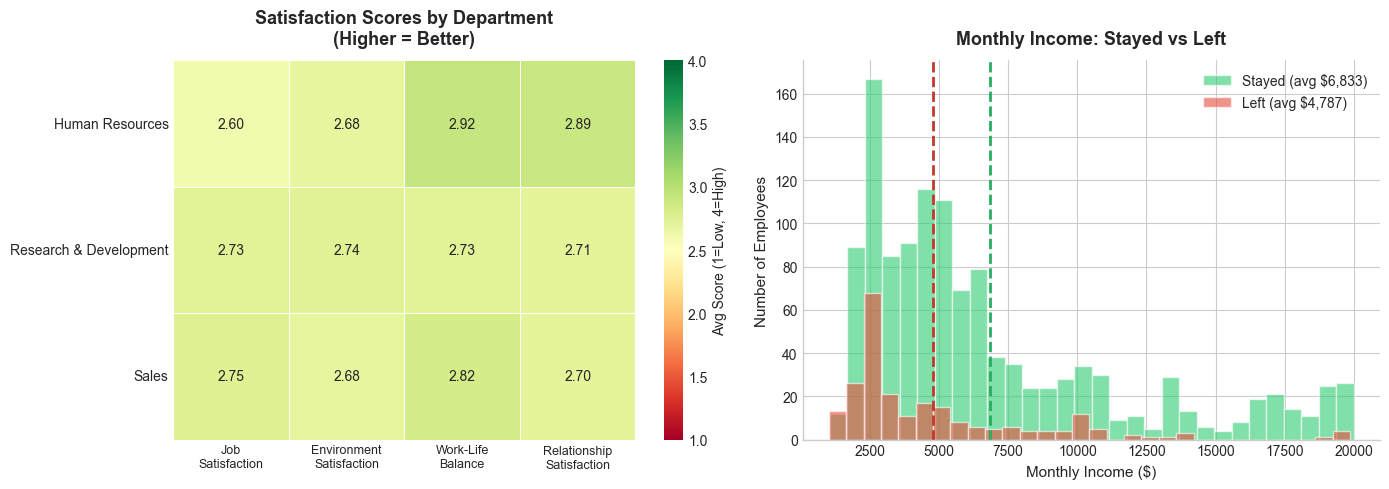

Chart saved!


In [15]:
# Build satisfaction matrix by department
satisfaction_cols = ['JobSatisfaction', 'EnvironmentSatisfaction',
                     'WorkLifeBalance', 'RelationshipSatisfaction']

sat_matrix = df_clean.groupby('Department')[satisfaction_cols].mean().round(2)
sat_matrix.columns = ['Job\nSatisfaction', 'Environment\nSatisfaction',
                      'Work-Life\nBalance', 'Relationship\nSatisfaction']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Satisfaction heatmap by department
sns.heatmap(sat_matrix,
            annot=True, fmt='.2f',
            cmap='RdYlGn',
            vmin=1, vmax=4,
            linewidths=0.5,
            linecolor='white',
            ax=axes[0],
            cbar_kws={'label': 'Avg Score (1=Low, 4=High)'})
axes[0].set_title('Satisfaction Scores by Department\n(Higher = Better)',
                  fontsize=13, fontweight='bold', pad=12)
axes[0].set_ylabel('')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0, fontsize=9)

# Chart 2: Monthly income distribution — stayed vs left
stayed = df_clean[df_clean['Attrition'] == 'No']['MonthlyIncome']
left   = df_clean[df_clean['Attrition'] == 'Yes']['MonthlyIncome']

axes[1].hist(stayed, bins=30, alpha=0.6, color='#2ECC71',
             label=f'Stayed (avg ${stayed.mean():,.0f})', edgecolor='white')
axes[1].hist(left,   bins=30, alpha=0.6, color='#E74C3C',
             label=f'Left (avg ${left.mean():,.0f})', edgecolor='white')
axes[1].axvline(stayed.mean(), color='#27AE60', linewidth=2, linestyle='--')
axes[1].axvline(left.mean(),   color='#C0392B', linewidth=2, linestyle='--')
axes[1].set_title('Monthly Income: Stayed vs Left',
                  fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel('Monthly Income ($)', fontsize=11)
axes[1].set_ylabel('Number of Employees', fontsize=11)
axes[1].legend(fontsize=10)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../Visuals/03_satisfaction_and_income.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

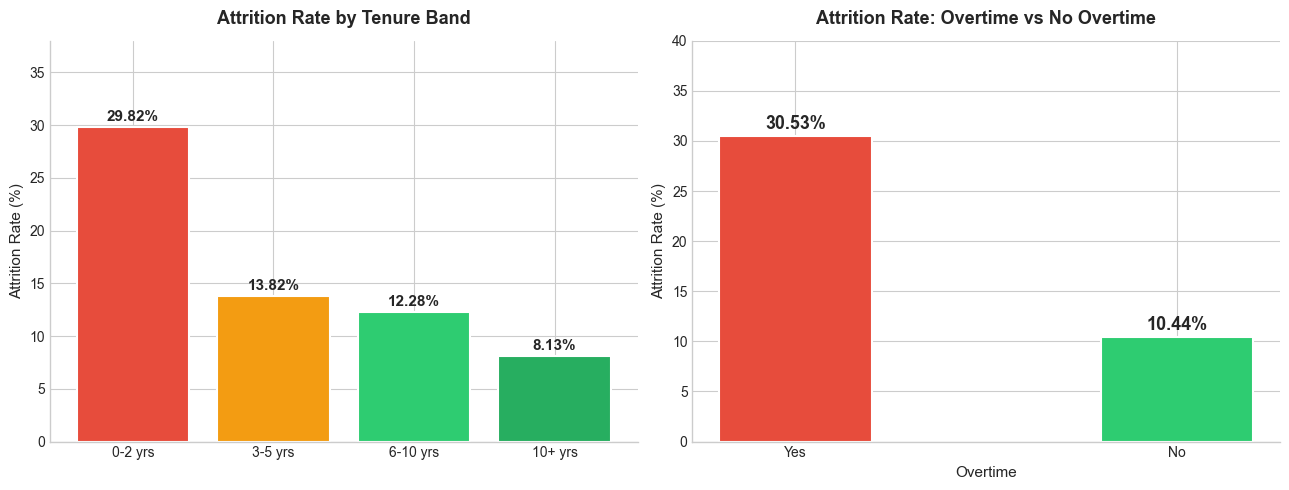

Chart saved!


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Chart 1: Attrition by tenure band
ten_order  = ['0-2 yrs', '3-5 yrs', '6-10 yrs', '10+ yrs']
ten_colors = ['#E74C3C', '#F39C12', '#2ECC71', '#27AE60']
ten_plot   = tenure_attrition.set_index('TenureBand').reindex(ten_order).reset_index()
bars = axes[0].bar(ten_plot['TenureBand'],
                   ten_plot['attrition_rate_pct'],
                   color=ten_colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, ten_plot['attrition_rate_pct']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f'{val}%', ha='center', va='bottom',
                 fontsize=11, fontweight='bold')
axes[0].set_title('Attrition Rate by Tenure Band',
                  fontsize=13, fontweight='bold', pad=12)
axes[0].set_ylabel('Attrition Rate (%)', fontsize=11)
axes[0].set_ylim(0, 38)
axes[0].spines[['top', 'right']].set_visible(False)

# Chart 2: Overtime vs attrition
ot_colors = ['#E74C3C', '#2ECC71']
bars2 = axes[1].bar(overtime_attrition['OverTime'],
                    overtime_attrition['attrition_rate_pct'],
                    color=ot_colors, width=0.4,
                    edgecolor='white', linewidth=1.5)
for bar, val in zip(bars2, overtime_attrition['attrition_rate_pct']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f'{val}%', ha='center', va='bottom',
                 fontsize=13, fontweight='bold')
axes[1].set_title('Attrition Rate: Overtime vs No Overtime',
                  fontsize=13, fontweight='bold', pad=12)
axes[1].set_ylabel('Attrition Rate (%)', fontsize=11)
axes[1].set_xlabel('Overtime', fontsize=11)
axes[1].set_ylim(0, 40)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../Visuals/04_tenure_and_overtime.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

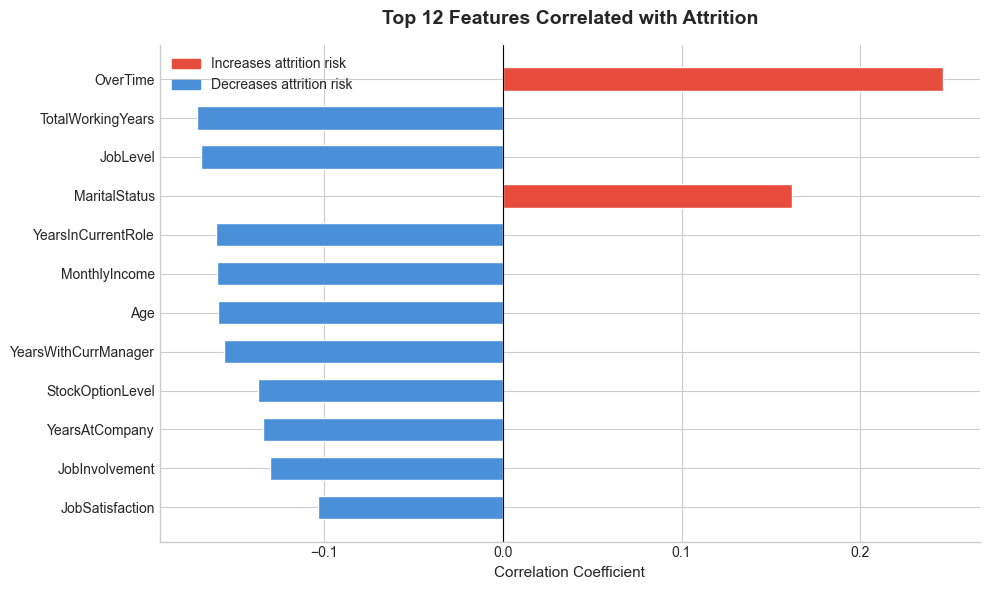

Chart saved!


In [17]:
# Encode for correlation
df_enc = df_clean.copy()
le = LabelEncoder()
cat_cols = df_enc.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c not in ['Attrition', 'SalaryBand', 'TenureBand']]
for col in cat_cols:
    df_enc[col] = le.fit_transform(df_enc[col].astype(str))

# Drop remaining non-numeric
df_enc = df_enc.drop(columns=['Attrition', 'SalaryBand', 'TenureBand'])
corr = df_enc.corr(numeric_only=True)['Attrition_Binary'].drop('Attrition_Binary')
corr_sorted = corr.abs().sort_values(ascending=False).head(12)
corr_vals   = corr[corr_sorted.index]

colors_corr = ['#E74C3C' if v > 0 else '#4A90D9' for v in corr_vals.values]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(corr_vals.index[::-1], corr_vals.values[::-1],
        color=colors_corr[::-1], edgecolor='white', height=0.6)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top 12 Features Correlated with Attrition',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Correlation Coefficient', fontsize=11)

red_p  = mpatches.Patch(color='#E74C3C', label='Increases attrition risk')
blue_p = mpatches.Patch(color='#4A90D9', label='Decreases attrition risk')
ax.legend(handles=[red_p, blue_p], fontsize=10)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../Visuals/05_feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

## Step 5: Logistic Regression — Predicting Attrition

We train a logistic regression model to:
1. Measure how accurately we can predict which employees will leave
2. Identify the top drivers of attrition from the model's coefficients
3. Generate a ranked list of currently active employees most at risk

**Business value:** HR can use this ranked list to proactively schedule 
retention conversations before an at-risk employee decides to resign.

In [18]:
# Prepare features
df_model = df_clean.copy()

# Drop columns not useful for modeling
drop_cols = ['Attrition', 'SalaryBand', 'TenureBand', 'EmployeeNumber']
df_model  = df_model.drop(columns=drop_cols)

# Encode all categorical columns
le   = LabelEncoder()
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

# Features and target
X = df_model.drop(columns=['Attrition_Binary'])
y = df_model['Attrition_Binary']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/test split — 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# Train logistic regression
model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
acc    = accuracy_score(y_test, y_pred)

print("=== LOGISTIC REGRESSION — MODEL PERFORMANCE ===")
print(f"Accuracy          : {acc*100:.2f}%")
print(f"Train samples     : {X_train.shape[0]:,}")
print(f"Test samples      : {X_test.shape[0]:,}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Stayed','Left']))

=== LOGISTIC REGRESSION — MODEL PERFORMANCE ===
Accuracy          : 75.17%
Train samples     : 1,176
Test samples      : 294

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.94      0.75      0.84       247
        Left       0.37      0.77      0.50        47

    accuracy                           0.75       294
   macro avg       0.66      0.76      0.67       294
weighted avg       0.85      0.75      0.78       294



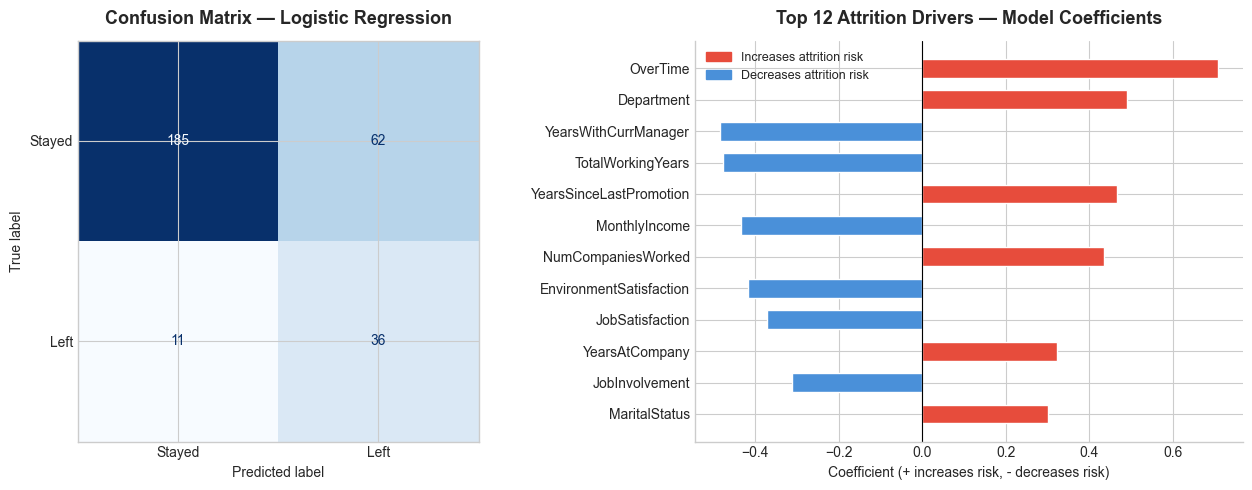

Chart saved!


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Chart 1: Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Stayed', 'Left'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix — Logistic Regression',
                  fontsize=13, fontweight='bold', pad=12)

# Chart 2: Feature importance from model coefficients
feature_names = X.columns.tolist()
coef_df = pd.DataFrame({
    'feature'    : feature_names,
    'coefficient': model.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False).head(12)

colors_coef = ['#E74C3C' if v > 0 else '#4A90D9'
               for v in coef_df['coefficient']]
axes[1].barh(coef_df['feature'][::-1],
             coef_df['coefficient'][::-1],
             color=colors_coef[::-1], edgecolor='white', height=0.6)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Top 12 Attrition Drivers — Model Coefficients',
                  fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel('Coefficient (+ increases risk, - decreases risk)', fontsize=10)
axes[1].spines[['top', 'right']].set_visible(False)

red_p  = mpatches.Patch(color='#E74C3C', label='Increases attrition risk')
blue_p = mpatches.Patch(color='#4A90D9', label='Decreases attrition risk')
axes[1].legend(handles=[red_p, blue_p], fontsize=9)

plt.tight_layout()
plt.savefig('../Visuals/06_model_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [20]:
# Get attrition probability for ALL currently active employees
# (Attrition = No, meaning they are still with the company)
df_active = df_clean[df_clean['Attrition'] == 'No'].copy()

# Re-encode the active employees
df_active_model = df_active.drop(
    columns=['Attrition', 'SalaryBand', 'TenureBand',
             'EmployeeNumber', 'Attrition_Binary'])

cat_cols2 = df_active_model.select_dtypes(include='object').columns.tolist()
le2 = LabelEncoder()
for col in cat_cols2:
    df_active_model[col] = le2.fit_transform(
        df_active_model[col].astype(str))

# Align columns with training data
df_active_model = df_active_model.reindex(columns=X.columns, fill_value=0)
X_active_scaled = scaler.transform(df_active_model)

# Predict attrition probability
attrition_probs = model.predict_proba(X_active_scaled)[:, 1]

# Build at-risk list
at_risk = df_active[['Department', 'JobRole', 'MonthlyIncome',
                      'YearsAtCompany', 'OverTime',
                      'JobSatisfaction']].copy()
at_risk['Attrition_Probability_%'] = (attrition_probs * 100).round(1)
at_risk = at_risk.sort_values('Attrition_Probability_%', ascending=False)

print("=== TOP 15 AT-RISK ACTIVE EMPLOYEES ===")
print(at_risk.head(15).to_string(index=False))

print(f"\n=== AT-RISK SUMMARY ===")
high_risk = (attrition_probs >= 0.7).sum()
med_risk  = ((attrition_probs >= 0.4) & (attrition_probs < 0.7)).sum()
low_risk  = (attrition_probs < 0.4).sum()
print(f"High risk  (>70% probability) : {high_risk:,} employees")
print(f"Medium risk (40-70%)          : {med_risk:,} employees")
print(f"Low risk   (<40%)             : {low_risk:,} employees")

=== TOP 15 AT-RISK ACTIVE EMPLOYEES ===
            Department                   JobRole  MonthlyIncome  YearsAtCompany OverTime  JobSatisfaction  Attrition_Probability_%
Research & Development Healthcare Representative           4741               5      Yes                1                    94.50
Research & Development        Research Scientist           2814               4      Yes                3                    91.90
                 Sales      Sales Representative           2380               2      Yes                1                    91.60
Research & Development     Laboratory Technician           2451               4       No                1                    91.20
                 Sales           Sales Executive           4157               2      Yes                4                    90.90
                 Sales           Sales Executive           4736               2      Yes                3                    89.40
                 Sales           Sales Exec

## Step 6: Business Recommendations

### Model Performance Summary

| Metric | Value |
|--------|-------|
| Overall Accuracy | 75.17% |
| Precision (Left class) | 37% |
| Recall (Left class) | 77% |
| Overall Attrition Rate | 16.12% (237 out of 1,470) |
| Top Driver of Attrition | OverTime (coefficient: +0.70) |
| Top Retention Factor | TotalWorkingYears / MonthlyIncome |
| High Risk Employees (>70%) | Check output from Cell 26 |

### 3 Business Recommendations

**Recommendation 1 — Eliminate mandatory overtime for Sales Representatives**
Sales Representatives have a 39.76% attrition rate — nearly 2.5x the company
average. OverTime is the single strongest predictor of attrition in the model.
Action: Cap overtime for Sales Reps at 5 hours/week and hire 10% additional
headcount to distribute workload. Retaining even 10 of the 33 who left
annually saves approximately $330K in replacement costs (est. $33K per hire).

**Recommendation 2 — Build a structured 90-day onboarding program**
Employees with 0-2 years tenure churn at 29.82% — nearly double the
company average. The first two years are the highest-risk window.
Action: Assign every new hire a senior mentor for the first 90 days,
conduct 30/60/90-day check-ins, and tie manager bonuses to new hire
retention at the 12-month mark.

**Recommendation 3 — Raise base salary for Low band employees**
Employees earning below $3K/month churn at 28.61% vs 8.90% for top earners
— a 3.2x gap. MonthlyIncome is a top negative coefficient in the model
(higher income = lower attrition risk).
Action: Conduct a compensation benchmarking study and target a 15% salary
increase for bottom-quartile earners. At average replacement cost of $33K,
reducing attrition in this band by just 20 employees saves $660K annually.

---
*Analysis by: Parshwa Gandhi

In [21]:
# Export for Tableau
tableau_cols = ['Age', 'Department', 'JobRole', 'Attrition',
                'Attrition_Binary', 'MonthlyIncome', 'SalaryBand',
                'YearsAtCompany', 'TenureBand', 'OverTime',
                'JobSatisfaction', 'EnvironmentSatisfaction',
                'WorkLifeBalance', 'RelationshipSatisfaction',
                'BusinessTravel', 'MaritalStatus', 'Gender',
                'JobLevel', 'NumCompaniesWorked', 'TotalWorkingYears',
                'YearsInCurrentRole', 'StockOptionLevel']

df_tableau = df_clean[tableau_cols].copy()
df_tableau.to_csv('../Data/hr_attrition_tableau.csv', index=False)
print(f"Exported {len(df_tableau):,} rows to /Data/hr_attrition_tableau.csv")
print(f"Columns: {df_tableau.columns.tolist()}")

Exported 1,470 rows to /Data/hr_attrition_tableau.csv
Columns: ['Age', 'Department', 'JobRole', 'Attrition', 'Attrition_Binary', 'MonthlyIncome', 'SalaryBand', 'YearsAtCompany', 'TenureBand', 'OverTime', 'JobSatisfaction', 'EnvironmentSatisfaction', 'WorkLifeBalance', 'RelationshipSatisfaction', 'BusinessTravel', 'MaritalStatus', 'Gender', 'JobLevel', 'NumCompaniesWorked', 'TotalWorkingYears', 'YearsInCurrentRole', 'StockOptionLevel']
